# Variance Clock Construction for EUR/USD

This notebook builds a **variance (volatility) clock**: instead of sampling the price process at fixed calendar intervals, we sample it at fixed increments of *quadratic variation*.

By the Dubins–Schwarz theorem, any continuous local martingale $M_t$ can be written as a time-changed Brownian motion:

$$M_t = B_{\langle M \rangle_t}$$

where $\langle M \rangle_t$ is the quadratic variation process and $B$ is a standard Brownian motion. Sampling $M$ at the stopping times where $\langle M \rangle_t$ crosses evenly spaced thresholds $i\Delta$ should recover increments that look like i.i.d. $N(0,\Delta)$ — i.e. the volatility clustering visible in calendar time should disappear in "volatility time".

In [42]:
from datetime import datetime, timedelta
import dukascopy_python
from dukascopy_python.instruments import INSTRUMENT_FX_MAJORS_EUR_USD
import numpy as np
import pandas as pd



## 1. Load raw tick data

We need tick-level bid/ask quotes to compute realized quadratic variation at the finest available resolution.

In [43]:
from pathlib import Path

start = datetime(2025, 1, 1)
end = datetime(2025, 12, 31)

parquet_path = Path("raw_ticks_cache.parquet")

if parquet_path.exists():
    raw_ticks = pd.read_parquet(parquet_path)
    print(f"Loaded {len(raw_ticks):,} ticks from {parquet_path}")
else:
    raw_ticks = dukascopy_python.fetch(
        instrument=INSTRUMENT_FX_MAJORS_EUR_USD,
        interval=dukascopy_python.INTERVAL_TICK,
        offer_side=dukascopy_python.OFFER_SIDE_BID,
        start=start,
        end=end,
    )
    parquet_path.parent.mkdir(parents=True, exist_ok=True)
    raw_ticks.to_parquet(parquet_path, index=True, compression="snappy")
    print(f"Fetched {len(raw_ticks):,} ticks")
    print(f"Saved parquet: {parquet_path}")

print(f"Columns: {list(raw_ticks.columns)}")
print(f"Range: {raw_ticks.index.min()} -> {raw_ticks.index.max()}")
raw_ticks.head()

Loaded 23,409,558 ticks from raw_ticks_cache.parquet
Columns: ['bidPrice', 'askPrice', 'bidVolume', 'askVolume']
Range: 2025-01-01 22:00:14.647000+00:00 -> 2025-12-30 22:59:47.863000+00:00


,bidPrice,askPrice,bidVolume,askVolume
timestamp,,,,
2025-01-01 22:00:14.647000+00:00,1.03503,1.03591,4.50,4.50
2025-01-01 22:00:14.949000+00:00,1.03510,1.03585,0.72,0.72
2025-01-01 22:00:19.212000+00:00,1.03514,1.03585,0.75,0.72
2025-01-01 22:02:34.026000+00:00,1.03514,1.03590,0.75,4.50
2025-01-01 22:04:01.734000+00:00,1.03514,1.03612,0.75,0.90


## 2. Mid price

$$P_t = \frac{P_t^{\text{bid}} + P_t^{\text{ask}}}{2}$$

In [44]:
raw_ticks['mid'] = (raw_ticks['bidPrice']+ raw_ticks['askPrice'])/2
raw_ticks['mid'].head()

timestamp
2025-01-01 22:00:14.647000+00:00    1.035470
2025-01-01 22:00:14.949000+00:00    1.035475
2025-01-01 22:00:19.212000+00:00    1.035495
2025-01-01 22:02:34.026000+00:00    1.035520
2025-01-01 22:04:01.734000+00:00    1.035630
Name: mid, dtype: float64

## 3. Resample to a regular calendar grid

Ticks arrive irregularly, so we resample the mid price onto a fixed 1-second grid, forward-filling gaps:

$$P_t^{(1s)} = \text{last observed } P_s \text{ for } s \le t$$

In [45]:
d = raw_ticks['mid'].resample('1s').last().ffill()

In [46]:
d = pd.DataFrame(d)

In [47]:
d.columns

Index(['mid'], dtype='str')

## 4. Log returns and squared returns

$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right), \qquad Y_t = r_t^2$$

$Y_t$ is the per-step contribution to realized quadratic variation.

In [48]:
d['log_return'] = np.log(d['mid']/d['mid'].shift(1))
Y= np.square(d['log_return'])

## 5. Realized quadratic variation (the volatility odometer)

$$\langle M \rangle_t = \sum_{s \le t} r_s^2$$

This discretized quadratic variation is the running total of squared returns — the "odometer" reading that the variance clock uses instead of calendar time.

In [49]:
d['cumul_sum'] =np.cumsum(Y) #realized quadratic variation your discretized ⟨M⟩_t, evaluated at every tick. This is the volatility odometer reading after each tick.


In [50]:
Z = d['cumul_sum']

## 6. Choosing the clock increment $\Delta$

We divide the total accumulated quadratic variation over the sample into $N$ equal-sized bars:

$$\Delta = \frac{\langle M \rangle_T}{N}$$

where $T$ is the end of the sample and $N$ is the target number of bars (here $N=400$).

In [51]:
total_qv = Z.iloc[-1]
delta = total_qv /400

In [52]:
print(delta)

1.7460424881165406e-05


## 7. The variance-clock stopping times

Each new "bar" begins the first time $\langle M \rangle_t$ crosses the next multiple of $\Delta$:

$$\tau_i = \inf\{t : \langle M \rangle_t \ge i\Delta\}, \qquad \text{bar\_id}(t) = \left\lfloor \frac{\langle M \rangle_t}{\Delta} \right\rfloor$$

`new_bar` flags the ticks where the bar index increments, i.e. the stopping times $\tau_i$.

In [53]:
bar_id = np.floor(Z/ delta)
new_bar = bar_id.diff().fillna(0) > 0

## 8. Cumulative signed return $M_t$

$$M_t = \sum_{s \le t} r_s$$

This is the continuous local martingale that the Dubins–Schwarz time change applies to.

In [54]:
M = d['log_return'].cumsum() # M_t: cumulative return

## 9. Time-changed process $B_t$

Sampling $M$ at the variance-clock stopping times gives the Dubins–Schwarz Brownian motion:

$$B_i = M_{\tau_i}$$

with $B_0 = 0$ by convention. If the time change is doing its job, the increments $B_i - B_{i-1}$ should be approximately i.i.d. $N(0, \Delta)$, independent of the volatility clustering present in calendar-time returns.

In [55]:
Bt = M[new_bar]

In [56]:
Bt = pd.concat([pd.Series([0.0]), Bt]).reset_index(drop=True)

In [57]:
M.iloc[0] = 0

In [58]:
M.iloc[0]

np.float64(0.0)

## 10. Validating $B_t$ as Brownian motion

Under the null that the variance clock has absorbed volatility clustering, the increments

$$\Delta B_i = B_i - B_{i-1}$$

should be (i) approximately Gaussian (QQ-plot / Jarque–Bera), (ii) serially uncorrelated (ACF / Ljung–Box on $\Delta B_i$), and (iii) show **no** residual clustering in $(\Delta B_i)^2$ (ACF / Ljung–Box on squared increments — the key diagnostic).

Increment stats:
count    389.000000
mean       0.000330
std        0.004083
min       -0.016142
25%       -0.002410
50%        0.000162
75%        0.002599
max        0.011981
dtype: float64
mean=3.301687e-04  var=1.666892e-05



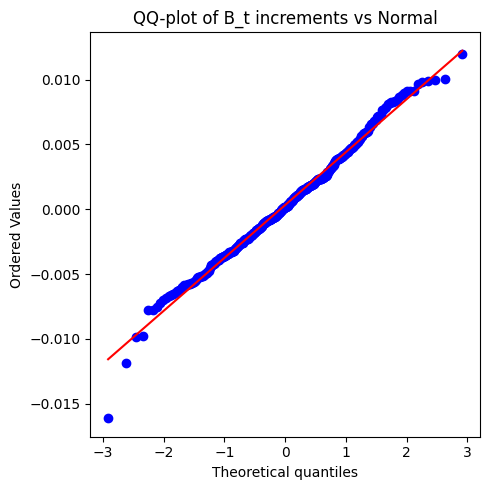

Jarque-Bera normality test: stat=2.481, p=0.2892
  (large samples make JB oversensitive to tiny deviations -- eyeball the QQ-plot too, don't rely on the p-value alone)



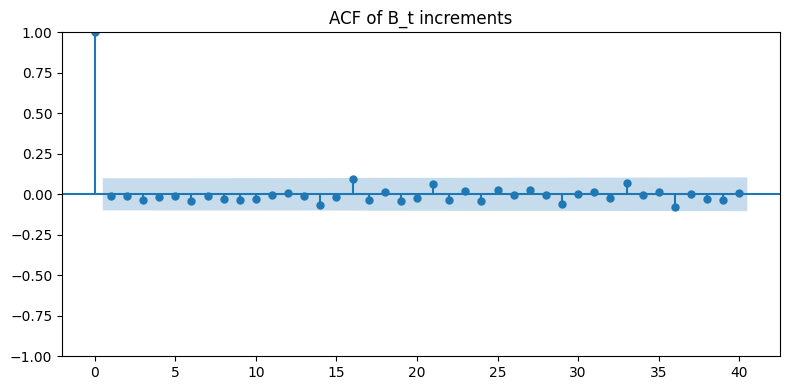

Ljung-Box on raw increments (want: p-values NOT small):
      lb_stat  lb_pvalue
10   2.471701   0.991282
20   9.619174   0.974564
40  20.941667   0.994374 



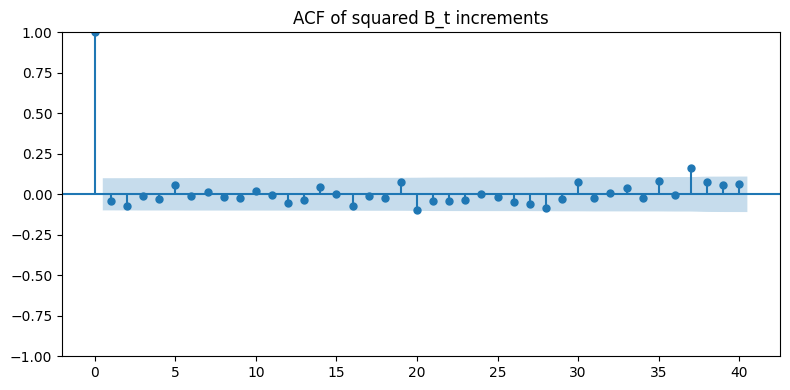

Ljung-Box on squared increments (want: p-values NOT small):
      lb_stat  lb_pvalue
10   5.010918   0.890447
20  16.239741   0.701644
40  47.420002   0.195793 

Interpretation:
- QQ-plot hugging the diagonal + high JB p-value -> increments look Gaussian
- Ljung-Box on raw increments: not very informative on its own
  (FX returns are usually already ~uncorrelated in calendar time)
- Ljung-Box on SQUARED increments is the key test:
  small p-values -> still volatility clustering, Delta may be too coarse
  or QV estimate too noisy (revisit microstructure-noise handling)
  large p-values -> clustering absorbed by the variance clock, as expected


In [59]:
"""
Validate whether B_t (M sampled at the variance-clock stopping times T_t)
behaves like standard Brownian motion.

Assumes you already have `Bt`: a pandas Series of B_t values, indexed
0, 1, 2, ... (bar number), e.g. from:

    Bt = M[new_bar]
    Bt = pd.concat([pd.Series([0.0]), Bt]).reset_index(drop=True)
"""

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# ---- 0. Increments of B_t -------------------------------------------------
dBt = Bt.diff().dropna()

print("Increment stats:")
print(dBt.describe())
print(f"mean={dBt.mean():.6e}  var={dBt.var():.6e}\n")

# ---- 1. QQ-plot: are increments ~ Gaussian at bar-Delta scale? -----------
fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(dBt, dist="norm", plot=ax)
ax.set_title("QQ-plot of B_t increments vs Normal")
plt.tight_layout()
plt.show()

jb_stat, jb_p = stats.jarque_bera(dBt)
print(f"Jarque-Bera normality test: stat={jb_stat:.3f}, p={jb_p:.4f}")
print("  (large samples make JB oversensitive to tiny deviations -- "
      "eyeball the QQ-plot too, don't rely on the p-value alone)\n")

# ---- 2. ACF of raw increments: should already be ~0 at all lags ---------
# (true Brownian increments are iid, so this should hold even before the
# time-change -- it's the squared-increment test below that's diagnostic)
fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(dBt, lags=40, ax=ax)
ax.set_title("ACF of B_t increments")
plt.tight_layout()
plt.show()

lb_returns = acorr_ljungbox(dBt, lags=[10, 20, 40], return_df=True)
print("Ljung-Box on raw increments (want: p-values NOT small):")
print(lb_returns, "\n")

# ---- 3. ACF of SQUARED increments: THE real test for volatility clustering
sq_dBt = dBt**2

fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(sq_dBt, lags=40, ax=ax)
ax.set_title("ACF of squared B_t increments")
plt.tight_layout()
plt.show()

lb_sq = acorr_ljungbox(sq_dBt, lags=[10, 20, 40], return_df=True)
print("Ljung-Box on squared increments (want: p-values NOT small):")
print(lb_sq, "\n")

# ---- 4. Optional: side-by-side comparison against naive calendar-time ----
# Run the same three checks (QQ, ACF, Ljung-Box on squares) on a fixed
# calendar-interval return series (e.g. your onesec / 1-minute returns).
# If the time-change is doing its job, the calendar-time squared returns
# should show strong, significant autocorrelation (small p-values --
# classic volatility clustering) while the B_t squared increments above
# should not. That contrast is your evidence the Dubins-Schwarz time-change
# is working on this data.

print("Interpretation:")
print("- QQ-plot hugging the diagonal + high JB p-value -> increments look Gaussian")
print("- Ljung-Box on raw increments: not very informative on its own")
print("  (FX returns are usually already ~uncorrelated in calendar time)")
print("- Ljung-Box on SQUARED increments is the key test:")
print("  small p-values -> still volatility clustering, Delta may be too coarse")
print("  or QV estimate too noisy (revisit microstructure-noise handling)")
print("  large p-values -> clustering absorbed by the variance clock, as expected")

**Interpretation of the $N=400$ run:**

- **Increment moments:** $\Delta B_i$ has mean $\approx 3.3\times 10^{-4}$ and variance $\approx 1.67\times 10^{-5}$ over 389 increments — close to zero-mean, and the variance is the right order of magnitude given $\Delta \approx 1.75\times 10^{-5}$.
- **Normality (Jarque–Bera):** stat $=2.481$, $p=0.289$ — we fail to reject Gaussianity of the increments, consistent with the QQ-plot hugging the diagonal.
- **Raw autocorrelation (Ljung–Box on $\Delta B_i$):** $p=0.99, 0.97, 0.99$ at lags 10/20/40 — no detectable serial correlation, as expected (FX returns are already close to uncorrelated even in calendar time, so this test alone isn't strong evidence for the clock).
- **Squared autocorrelation (Ljung–Box on $\Delta B_i^2$):** $p=0.89, 0.70, 0.20$ at lags 10/20/40 — all comfortably above 0.05, meaning **no significant leftover volatility clustering** in volatility time. This is the key result: at $N=400$ bars the variance clock appears to have absorbed the clustering that would otherwise show up in calendar-time squared returns.

## 11. Calendar-time control comparison

As a control, we run the identical battery of tests (QQ-plot, Jarque–Bera, Ljung–Box on raw and squared increments) on the **calendar-time** 1-second log returns $r_t$. If the variance clock is working, the squared calendar-time returns should show significant autocorrelation (volatility clustering) where the squared $B_t$ increments do not.

Using 500,000 of 31,366,773 calendar-time returns
Calendar-time increment stats:
count    5.000000e+05
mean     2.480414e-09
std      1.524107e-05
min     -1.213084e-03
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.394252e-04
Name: log_return, dtype: float64
mean=2.480414e-09  var=2.322901e-10



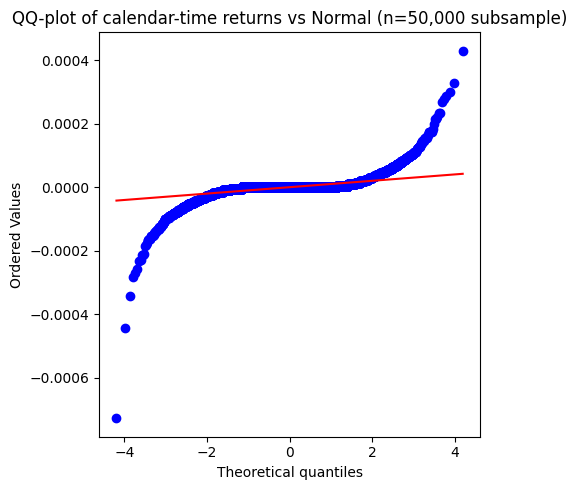

Jarque-Bera (calendar-time): stat=1074348583.308, p=0.0000



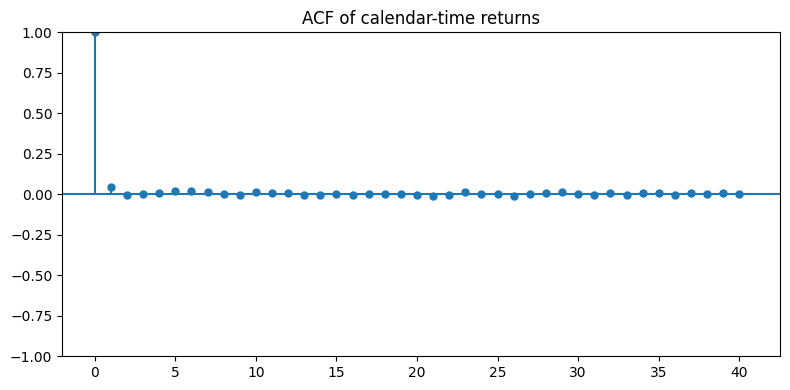

Ljung-Box on calendar-time returns (raw):
        lb_stat  lb_pvalue
10  1713.326701        0.0
20  1856.916285        0.0
40  2323.749734        0.0 



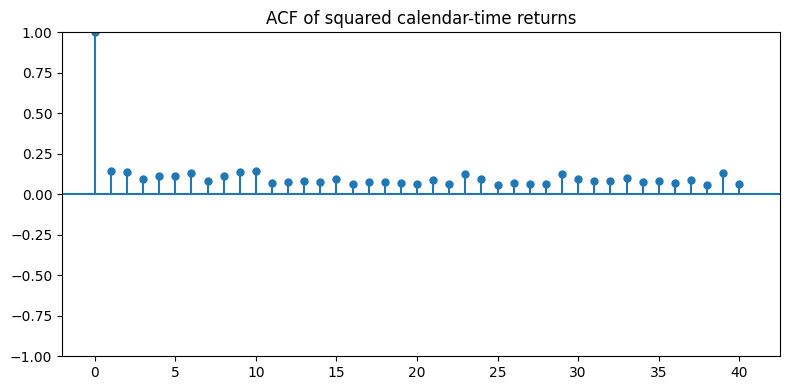

Ljung-Box on SQUARED calendar-time returns (expect small p-values here):
          lb_stat  lb_pvalue
10   73886.351845        0.0
20  101686.420315        0.0
40  177045.266366        0.0 

Comparison -- lb_sq p-value at lag 40:
  Calendar time (returns_1s): 0.0000
  Volatility time (B_t):      0.1958
If the time-change worked, the calendar-time number above should be
much smaller (more significant clustering) than the B_t number.


In [60]:
# ---- 4. Calendar-time comparison: does resampling actually help? ---------
# `d` covers a full calendar year at 1s resolution (~31.5M rows), which
# makes the QQ-plot scatter and repeated ACF/Ljung-Box passes below very
# slow. Work on a capped, contiguous subsample for fast iteration; bump
# MAX_POINTS (or set it to None) once you're ready to run the full-year
# version for real.
MAX_POINTS = 500_000

# NB: was `d.dropna()` (the whole frame, incl. price level `mid` and the
# monotonic `cumul_sum`) -- we only want the return series here.
calendar_returns_full = d['log_return'].dropna()
calendar_returns = (
    calendar_returns_full.iloc[:MAX_POINTS]
    if MAX_POINTS and len(calendar_returns_full) > MAX_POINTS
    else calendar_returns_full
)

print(f"Using {len(calendar_returns):,} of {len(calendar_returns_full):,} calendar-time returns")
print("Calendar-time increment stats:")
print(calendar_returns.describe())
print(f"mean={calendar_returns.mean():.6e}  var={calendar_returns.var():.6e}\n")

# QQ-plot + Jarque-Bera. Stats (JB, mean, var) run on the full capped
# series above; the scatter itself is further subsampled since plotting
# hundreds of thousands+ of individual markers is what actually crawls.
qq_sample = calendar_returns.sample(n=min(50_000, len(calendar_returns)), random_state=0)
fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(qq_sample, dist="norm", plot=ax)
for line in ax.get_lines():
    line.set_rasterized(True)
ax.set_title(f"QQ-plot of calendar-time returns vs Normal (n={len(qq_sample):,} subsample)")
plt.tight_layout()
plt.show()

jb_stat_cal, jb_p_cal = stats.jarque_bera(calendar_returns)
print(f"Jarque-Bera (calendar-time): stat={jb_stat_cal:.3f}, p={jb_p_cal:.4f}\n")

# ACF of raw calendar-time returns
fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(calendar_returns, lags=40, ax=ax, fft=True)
ax.set_title("ACF of calendar-time returns")
plt.tight_layout()
plt.show()

lb_cal_raw = acorr_ljungbox(calendar_returns, lags=[10, 20, 40], return_df=True)
print("Ljung-Box on calendar-time returns (raw):")
print(lb_cal_raw, "\n")

# ACF of SQUARED calendar-time returns -- expect THIS to fail (clustering)
sq_calendar = calendar_returns**2
fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(sq_calendar, lags=40, ax=ax, fft=True)
ax.set_title("ACF of squared calendar-time returns")
plt.tight_layout()
plt.show()

lb_cal_sq = acorr_ljungbox(sq_calendar, lags=[10, 20, 40], return_df=True)
print("Ljung-Box on SQUARED calendar-time returns (expect small p-values here):")
print(lb_cal_sq, "\n")

# ---- Side-by-side summary -------------------------------------------------
print("Comparison -- lb_sq p-value at lag 40:")
print(f"  Calendar time (returns_1s): {lb_cal_sq['lb_pvalue'].iloc[-1]:.4f}")
print(f"  Volatility time (B_t):      {lb_sq['lb_pvalue'].iloc[-1]:.4f}")
print("If the time-change worked, the calendar-time number above should be")
print("much smaller (more significant clustering) than the B_t number.")

## 12. Sensitivity to the number of bars $N$

We sweep $N \in \{50, 100, 150, 225, 400, 800\}$, recomputing $\Delta = \langle M \rangle_T / N$ and $B_i = M_{\tau_i}$ for each, and compare the Jarque–Bera and Ljung–Box diagnostics to find a bar count where $B_t$ is closest to genuine Brownian motion without over-thinning the sample.

In [61]:
"""
Sweep over candidate bar counts / delta values and compare how
"Brownian-like" the resulting B_t looks for each.

Requires: qv (the cumulative QV / odometer series, e.g. your 'cumul_sum'
column) and M (cumulative signed-return series, log_return.cumsum()),
both indexed the same way.
"""

import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
qv = Z

def build_Bt(qv: pd.Series, M: pd.Series, num_bars: int) -> pd.Series:
    total_qv = qv.iloc[-1]
    delta = total_qv / num_bars

    bar_id = np.floor(qv / delta)
    new_bar = bar_id.diff().fillna(0) > 0

    Bt = M[new_bar]
    Bt = pd.concat([pd.Series([0.0]), Bt]).reset_index(drop=True)
    return Bt, delta


def evaluate_delta(qv: pd.Series, M: pd.Series, num_bars: int, lags=(10, 20, 40)) -> dict:
    Bt, delta = build_Bt(qv, M, num_bars)
    dBt = Bt.diff().dropna()

    if len(dBt) < max(lags) + 5:
        # not enough bars to run the diagnostics meaningfully
        return {
            "num_bars": num_bars, "delta": delta, "n_increments": len(dBt),
            "jb_p": np.nan, "lb_raw_p_max_lag": np.nan, "lb_sq_p_max_lag": np.nan,
        }

    jb_stat, jb_p = stats.jarque_bera(dBt)
    lb_raw = acorr_ljungbox(dBt, lags=list(lags), return_df=True)
    lb_sq = acorr_ljungbox(dBt**2, lags=list(lags), return_df=True)

    return {
        "num_bars": num_bars,
        "delta": delta,
        "n_increments": len(dBt),
        "jb_p": jb_p,                                   # want: high
        "lb_raw_p_max_lag": lb_raw["lb_pvalue"].iloc[-1],  # want: high
        "lb_sq_p_max_lag": lb_sq["lb_pvalue"].iloc[-1],    # want: high (key test)
    }


# ---- sweep -----------------------------------------------------------
candidate_num_bars = [50, 100, 150, 225, 400, 800]

results = pd.DataFrame([
    evaluate_delta(qv, M, n) for n in candidate_num_bars
])

print(results.to_string(index=False))

# ---- how to read this table -------------------------------------------
# n_increments      -- sanity check: too few (<~50-100) and the p-values
#                       above aren't trustworthy regardless of their value
# jb_p              -- higher = increments look more Gaussian
# lb_raw_p_max_lag  -- higher = no leftover autocorrelation in raw increments
#                       (usually fine across the whole grid for FX)
# lb_sq_p_max_lag   -- higher = no leftover volatility clustering
#                       (THE diagnostic that should respond to delta choice --
#                       watch for it dropping as num_bars grows past some point,
#                       or staying low throughout if delta is never fine enough)
#
# Look for the region where lb_sq_p_max_lag is consistently high AND
# n_increments is large enough to trust that number. If it's high nowhere,
# the microstructure-noise handling (step 4) likely needs revisiting before
# delta-tuning alone will fix it.

 num_bars    delta  n_increments     jb_p  lb_raw_p_max_lag  lb_sq_p_max_lag
       50 0.000140            49 0.047997          0.461160         0.920225
      100 0.000070            98 0.031189          0.954825         0.000148
      150 0.000047           148 0.208675          0.299851         0.003855
      225 0.000031           222 0.586579          0.988196         0.046859
      400 0.000017           389 0.289231          0.994374         0.195793
      800 0.000009           771 0.017018          0.901262         0.856320


**Interpretation of the bar-count sweep:**

| $N$ | $\Delta$ | $n$ increments | JB $p$ | LB raw $p$ (lag 40) | LB sq $p$ (lag 40) |
|---:|---:|---:|---:|---:|---:|
| 50  | 1.40e-4 | 49  | 0.048 | 0.461 | **0.920** |
| 100 | 7.0e-5  | 98  | 0.031 | 0.955 | **0.0001** |
| 150 | 4.7e-5  | 148 | 0.209 | 0.300 | 0.004 |
| 225 | 3.1e-5  | 222 | 0.587 | 0.988 | 0.047 |
| 400 | 1.7e-5  | 389 | 0.289 | 0.994 | **0.196** |
| 800 | 0.9e-5  | 771 | 0.017 | 0.901 | **0.856** |

- The Ljung–Box-on-squares column (the diagnostic that actually tests whether volatility clustering has been absorbed) is **not monotonic in $N$**: it is low/borderline for $N \in \{100, 150, 225\}$ — meaning the clock is too coarse at those settings and clustering leaks through — then recovers at $N=400$ and is strongest at $N=800$.
- $N=800$ gives the cleanest clustering removal ($p=0.856$) but fails the Jarque–Bera normality check ($p=0.017$), i.e. the increments become non-Gaussian at very fine $\Delta$ — likely because each bar is now short enough that bid/ask bounce and other microstructure noise start to dominate the signed increment, producing heavier tails.
- $N=50$ also has both a low JB $p$ and a small sample (49 increments), so its high $p_{\text{sq}}=0.920$ is not very trustworthy — the Ljung–Box test has little power with so few observations.
- **$N=400$ is the best-supported choice in this sweep**: a large enough sample (389 increments) for the tests to be meaningful, a Gaussian-consistent JB $p$-value, and no significant residual clustering ($p_{\text{sq}}=0.196$) — without pushing $\Delta$ small enough to let microstructure noise contaminate the increments the way $N=800$ does.